# Evaluation: Basic vs Advanced Decision Router

I evaluate how the basic and advanced decision analysis implementations perform compared to the real event log.

**Metric:** Jensen-Shannon Divergence (JSD) — measures similarity between two probability distributions.  
- JSD = 0 → identical distributions  
- JSD = 1 → completely different distributions

We need to evaluate how the deicison analysis, the basic and advanced implementations

# Imports

In [157]:
%matplotlib inline
import argparse
import json
import os
import pickle
import sys
import warnings
from pathlib import Path

import pm4py
import numpy as np
import pandas as pd
import matplotlib

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from scipy.stats import chi2_contingency, ks_2samp
from scipy.spatial.distance import jensenshannon

warnings.filterwarnings("ignore")

In [158]:
#path names
BASE_DIR = Path("/Users/zeynepcetin/bppso-groupwork-1")

real_log_path   = BASE_DIR / "data" / "BPI Challenge 2017.xes.gz"
rules_path      = BASE_DIR / "decision_analysis" / "decision_prob_rules.json"
model_path      = BASE_DIR / "decision_analysis" / "simulation_brain.pkl"
sim_basic_path  = BASE_DIR / "decision_analysis" / "sim_output_basic.csv"
sim_adv_path    = BASE_DIR / "decision_analysis" / "sim_output_advanced.csv"
output_dir      = BASE_DIR / "decision_analysis" / "evaluation_results"

#Colors symbolizing..
c_real = "#0A917A"
c_basic = "#3498db"
c_advanced = "#e74c3c"
c_neutral = "#95a5a6"


# Helper Functions

In [159]:
def jsd_metric(p: dict, q: dict) -> float:
    """Jensen-Shannon Divergence between two discrete distributions given as dicts"""
    keys = sorted(set(p) | set(q))
    pv = np.array([p.get(k, 0.0) for k in keys], dtype=float)
    qv = np.array([q.get(k, 0.0) for k in keys], dtype=float)
    if pv.sum() > 0:
        pv /= pv.sum()
    if qv.sum() > 0:
        qv /= qv.sum()
    return float(jensenshannon(pv, qv))


def get_activity_freq(df: pd.DataFrame) -> dict:
    """Return normalised activity frequency distribution"""
    counts = df["concept:name"].value_counts()
    return (counts / counts.sum()).to_dict()


def get_empirical_transitions(df: pd.DataFrame) -> dict:
    """Compute empirical transition probabilities from an event log"""
    tmp = df.copy()
    tmp["_next"] = tmp.groupby("case:concept:name")["concept:name"].shift(-1)
    branching = tmp.dropna(subset=["_next"])
    branching = branching[branching["concept:name"] != branching["_next"]]
    result = {}
    for act, grp in branching.groupby("concept:name"):
        counts = grp["_next"].value_counts()
        result[act] = (counts / counts.sum()).to_dict()
    return result


def load_and_prepare(path, label=""):
    """Load a CSV simulation log, filter to completed events then sort"""
    df = pd.read_csv(path)
    df["time:timestamp"] = pd.to_datetime(df["time:timestamp"], utc=True, errors="coerce")
    if "lifecycle:transition" in df.columns:
        df = df[df["lifecycle:transition"].str.lower() == "complete"].copy()
    df = df.sort_values(["case:concept:name", "time:timestamp"])
    print(f"  [{label}] {len(df):,} events, {df['case:concept:name'].nunique():,} cases.")
    return df

# Loading the real event log

In [160]:
real_df = pm4py.convert_to_dataframe(pm4py.read_xes(str(real_log_path)))
real_df["time:timestamp"] = pd.to_datetime(real_df["time:timestamp"], utc=True)

if "lifecycle:transition" in real_df.columns:
        real_df = real_df[real_df["lifecycle:transition"].str.lower() == "complete"].copy()

real_df = real_df.sort_values(["case:concept:name", "time:timestamp"])
print(f"   [Real Log] {len(real_df):,} completed events, {real_df['case:concept:name'].nunique():,} cases.")

parsing log, completed traces :: 100%|██████████| 31509/31509 [00:29<00:00, 1057.47it/s]


   [Real Log] 475,306 completed events, 31,509 cases.


# Loading simulation logs and decision rules table

In [161]:
# Basic simulation
df_basic = load_and_prepare(sim_basic_path, "Basic")

# Advanced simulation
df_adv = load_and_prepare(sim_adv_path, "Advanced")

# Basic probability rules
with open(rules_path) as f:
    basic_rules = json.load(f)
print(f"  [Rules] {len(basic_rules)} decision points loaded.")

# Advanced model
with open(model_path, "rb") as f:
    adv_pkg = pickle.load(f)
adv_model = adv_pkg["model"]
adv_bins  = adv_pkg["bins"]
print(f"  [Advanced Model] loaded successfully.")

  [Basic] 7,569 events, 1,654 cases.
  [Advanced] 6,917 events, 1,657 cases.
  [Rules] 24 decision points loaded.
  [Advanced Model] loaded successfully.


In [162]:
# Filter simulation logs to completed cases (≥ 3 complete events).
# Right-censored cases (spawned near end of 14-day window) have only
# 1–2 complete events; including them inflates A_Create Application
# share and distorts transition probabilities & case length distributions.
# Real log is kept as-is (reference distribution, no artificial truncation).

def filter_completed(df, min_events=3, label=""):
    case_len = df.groupby("case:concept:name").size()
    completed_idx = case_len[case_len >= min_events].index
    df_comp = df[df["case:concept:name"].isin(completed_idx)].copy()
    n_all  = case_len.shape[0]
    n_comp = len(completed_idx)
    print(f"  [{label}] {n_comp} / {n_all} cases have ≥ {min_events} complete events "
          f"({n_comp/n_all*100:.1f}%)")
    return df_comp

print("Filtering simulation logs to completed cases:")
df_basic_comp = filter_completed(df_basic, min_events=3, label="Basic")
df_adv_comp   = filter_completed(df_adv,   min_events=3, label="Advanced")

Filtering simulation logs to completed cases:
  [Basic] 249 / 1654 cases have ≥ 3 complete events (15.1%)
  [Advanced] 240 / 1657 cases have ≥ 3 complete events (14.5%)


I want to compare how my basic and advanced router differ from the event log. Thus, I decided to compare the data distributions between basic vs real, advanced vs real. For this evaluation I decided to use Jensen-Shannon Divergence because it is a good metric for goodness of fit. The main goal with JS Divergence is to find out the similarity between two probability distributions. 

## Decision Point Quality (JSD per decision point)
Compare transition probabilities at each decision point: **Basic rules vs Real** and **Advanced sim vs Real**.

In [163]:
real_trans  = get_empirical_transitions(real_df)
basic_trans = get_empirical_transitions(df_basic_comp)
adv_trans   = get_empirical_transitions(df_adv_comp)

rows = []
for act, real_dist in sorted(real_trans.items()):
    # Only consider genuine decision points (more than one likely successor)
    if len([v for v in real_dist.values() if v > 0.01]) <= 1:
        continue

    b_dist = basic_trans.get(act, {})
    a_dist = adv_trans.get(act, {})

    b_jsd = jsd_metric(real_dist, b_dist) if b_dist else np.nan
    a_jsd = jsd_metric(real_dist, a_dist) if a_dist else np.nan

    rows.append({
        "Activity": act,
        "Basic JSD": round(b_jsd, 4) if not np.isnan(b_jsd) else None,
        "Advanced JSD": round(a_jsd, 4) if not np.isnan(a_jsd) else None,
    })

df_jsd = pd.DataFrame(rows).dropna(subset=["Basic JSD", "Advanced JSD"])
df_jsd = df_jsd.sort_values("Basic JSD", ascending=True)
print("Decision Point JSD (completed cases only):")
print(df_jsd.to_string(index=False))

Decision Point JSD (completed cases only):
                Activity  Basic JSD  Advanced JSD
              O_Returned     0.3725        0.3772
    A_Create Application     0.3753        0.2183
               A_Pending     0.4595        0.4595
               O_Created     0.4787        0.4534
             O_Cancelled     0.5318        0.5258
O_Sent (mail and online)     0.5638        0.5638
             A_Submitted     0.6712        0.6712
            A_Validating     0.7123        0.1449
            A_Incomplete     0.7341        0.6054
              A_Complete     0.8208        0.8208
  W_Validate application     0.8323        0.7623


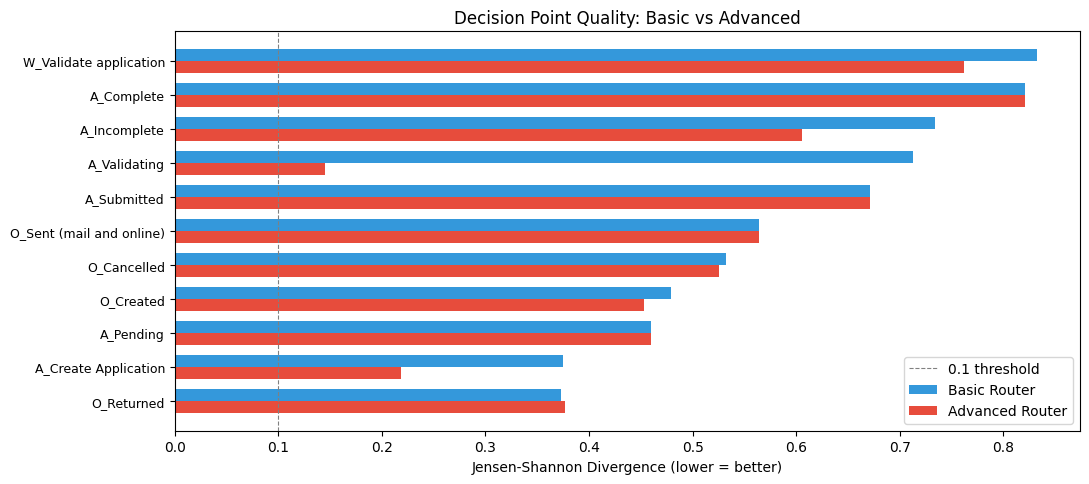

In [164]:
fig, ax = plt.subplots(figsize=(11, max(4, len(df_jsd) * 0.45)))

y = np.arange(len(df_jsd))
bar_h = 0.35

ax.barh(y + bar_h/2, df_jsd["Basic JSD"],    bar_h, label="Basic Router",    color=c_basic)
ax.barh(y - bar_h/2, df_jsd["Advanced JSD"],  bar_h, label="Advanced Router", color=c_advanced)

ax.set_yticks(y)
ax.set_yticklabels(df_jsd["Activity"], fontsize=9)
ax.set_xlabel("Jensen-Shannon Divergence (lower = better)")
ax.set_title("Decision Point Quality: Basic vs Advanced")
ax.axvline(0.1, color="grey", ls="--", lw=0.8, label="0.1 threshold")
ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig(output_dir / "decision_point_jsd.png", dpi=150)
plt.show()

# Activity Frequency Distribution

  Activity Frequency JSD — Basic:    0.3175
  Activity Frequency JSD — Advanced: 0.3282
  (sim logs: completed cases only; real log: all cases)


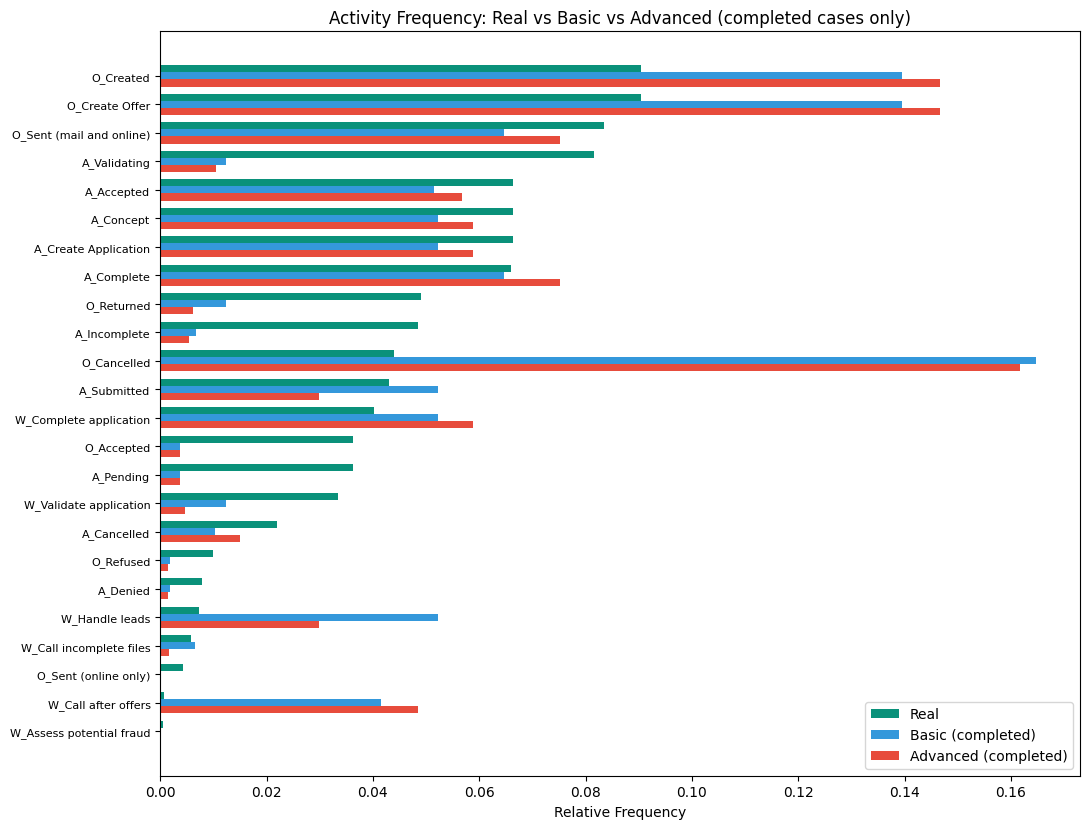

In [165]:
real_af  = get_activity_freq(real_df)
basic_af = get_activity_freq(df_basic_comp)
adv_af   = get_activity_freq(df_adv_comp)

jsd_basic_af = jsd_metric(real_af, basic_af)
jsd_adv_af   = jsd_metric(real_af, adv_af)

print(f"  Activity Frequency JSD — Basic:    {jsd_basic_af:.4f}")
print(f"  Activity Frequency JSD — Advanced: {jsd_adv_af:.4f}")
print("  (sim logs: completed cases only; real log: all cases)")

# Build comparison dataframe
all_acts = sorted(set(real_af) | set(basic_af) | set(adv_af))
comp = pd.DataFrame({
    "Activity": all_acts,
    "Real":     [real_af.get(a, 0) for a in all_acts],
    "Basic":    [basic_af.get(a, 0) for a in all_acts],
    "Advanced": [adv_af.get(a, 0) for a in all_acts],
}).sort_values("Real", ascending=True)

fig, ax = plt.subplots(figsize=(11, max(5, len(comp) * 0.35)))
y = np.arange(len(comp))
bw = 0.25

ax.barh(y + bw, comp["Real"],     bw, label="Real",     color=c_real)
ax.barh(y,      comp["Basic"],    bw, label="Basic (completed)",    color=c_basic)
ax.barh(y - bw, comp["Advanced"], bw, label="Advanced (completed)", color=c_advanced)

ax.set_yticks(y)
ax.set_yticklabels(comp["Activity"], fontsize=8)
ax.set_xlabel("Relative Frequency")
ax.set_title("Activity Frequency: Real vs Basic vs Advanced (completed cases only)")
ax.legend()
plt.tight_layout()
plt.savefig(output_dir / "activity_frequency.png", dpi=150)
plt.show()

#These activities are missing in our BPMN model: 
*{'O_Sent (online only)',
 'W_Assess potential fraud',
 'W_Personal Loan collection',
 'W_Shortened completion '}*

# Case Length Distribution

Case length (complete events per case):
  Real    — mean: 15.1, median: 14
  Basic   — mean: 19.1, median: 16  (completed cases only)
  Advanced— mean: 17.0, median: 15  (completed cases only)


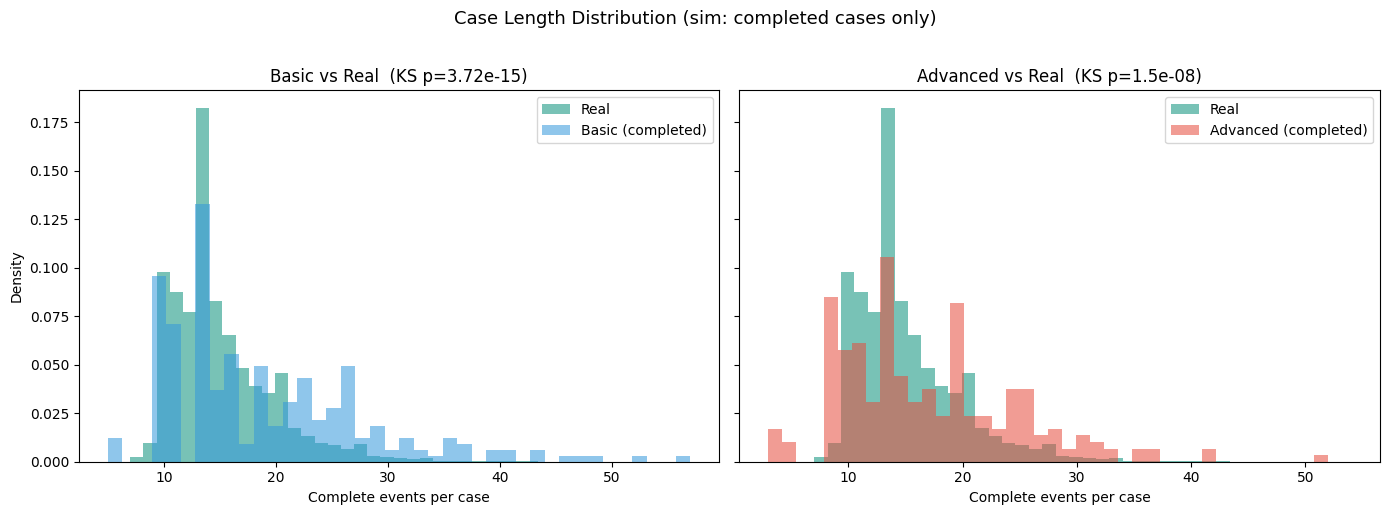


  KS test — Basic    vs Real: stat=0.2595, p=3.719e-15
  KS test — Advanced vs Real: stat=0.1968, p=1.498e-08


In [166]:
real_cl  = real_df.groupby("case:concept:name")["concept:name"].count()
basic_cl = df_basic_comp.groupby("case:concept:name")["concept:name"].count()
adv_cl   = df_adv_comp.groupby("case:concept:name")["concept:name"].count()

print(f"Case length (complete events per case):")
print(f"  Real    — mean: {real_cl.mean():.1f}, median: {real_cl.median():.0f}")
print(f"  Basic   — mean: {basic_cl.mean():.1f}, median: {basic_cl.median():.0f}  (completed cases only)")
print(f"  Advanced— mean: {adv_cl.mean():.1f}, median: {adv_cl.median():.0f}  (completed cases only)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Basic vs Real
axes[0].hist(real_cl,  bins=40, alpha=0.55, label="Real",  color=c_real,  density=True)
axes[0].hist(basic_cl, bins=40, alpha=0.55, label="Basic (completed)", color=c_basic, density=True)
ks_b = ks_2samp(real_cl, basic_cl)
axes[0].set_title(f"Basic vs Real  (KS p={ks_b.pvalue:.3g})")
axes[0].set_xlabel("Complete events per case")
axes[0].set_ylabel("Density")
axes[0].legend()

# Advanced vs Real
axes[1].hist(real_cl, bins=40, alpha=0.55, label="Real",     color=c_real,     density=True)
axes[1].hist(adv_cl,  bins=40, alpha=0.55, label="Advanced (completed)", color=c_advanced, density=True)
ks_a = ks_2samp(real_cl, adv_cl)
axes[1].set_title(f"Advanced vs Real  (KS p={ks_a.pvalue:.3g})")
axes[1].set_xlabel("Complete events per case")
axes[1].legend()

plt.suptitle("Case Length Distribution (sim: completed cases only)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(output_dir / "case_length_dist.png", dpi=150)
plt.show()

print(f"\n  KS test — Basic    vs Real: stat={ks_b.statistic:.4f}, p={ks_b.pvalue:.4g}")
print(f"  KS test — Advanced vs Real: stat={ks_a.statistic:.4f}, p={ks_a.pvalue:.4g}")

# Transition Probability Heatmaps

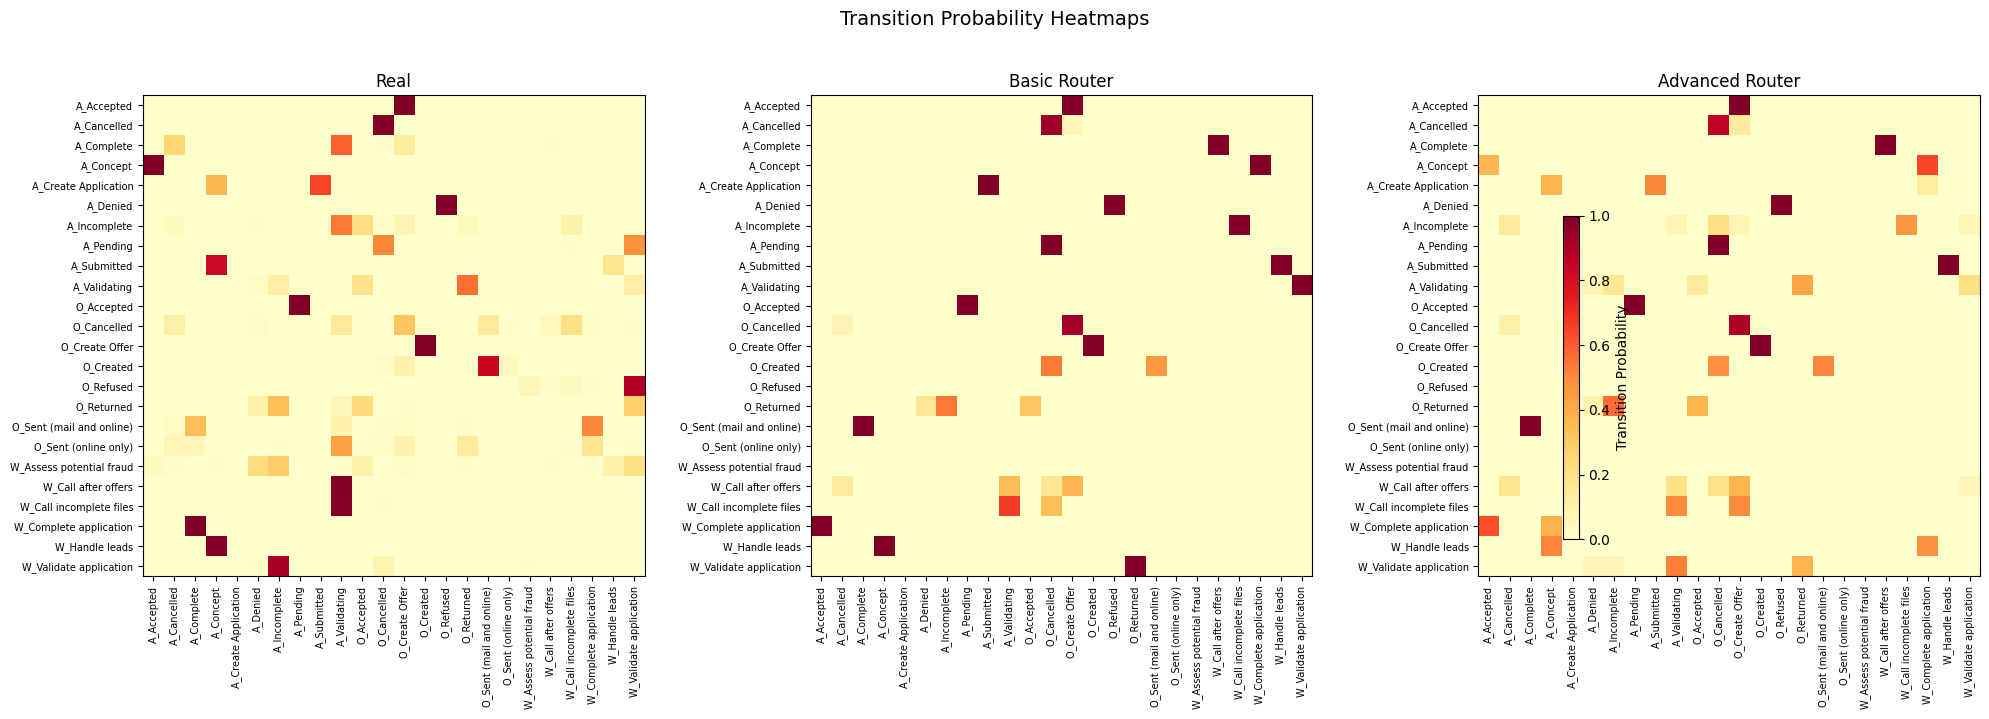

In [167]:
def trans_to_matrix(trans_dict, activities):
    """Convert transition dict to a DataFrame matrix."""
    mat = pd.DataFrame(0.0, index=activities, columns=activities)
    for src, dests in trans_dict.items():
        if src not in activities:
            continue
        for dst, prob in dests.items():
            if dst in activities:
                mat.loc[src, dst] = prob
    return mat

# Use only activities that appear in real transitions
acts = sorted(real_trans.keys())

real_mat  = trans_to_matrix(real_trans, acts)
basic_mat = trans_to_matrix(basic_trans, acts)
adv_mat   = trans_to_matrix(adv_trans, acts)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, mat, title in zip(axes,
                           [real_mat, basic_mat, adv_mat],
                           ["Real", "Basic Router", "Advanced Router"]):
    im = ax.imshow(mat.values, cmap="YlOrRd", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(acts)))
    ax.set_yticks(range(len(acts)))
    ax.set_xticklabels(acts, rotation=90, fontsize=7)
    ax.set_yticklabels(acts, fontsize=7)
    ax.set_title(title)

fig.colorbar(im, ax=axes, shrink=0.6, label="Transition Probability")
plt.suptitle("Transition Probability Heatmaps", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(output_dir / "transition_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()

# Results

In [168]:
summary = pd.DataFrame({
    "Metric": [
        "Activity Frequency JSD",
        "Mean Decision-Point JSD",
        "Case Length KS Statistic",
        "Case Length KS p-value",
    ],
    "Basic Router": [
        round(jsd_basic_af, 4),
        round(df_jsd["Basic JSD"].mean(), 4),
        round(ks_b.statistic, 4),
        f"{ks_b.pvalue:.4g}",
    ],
    "Advanced Router": [
        round(jsd_adv_af, 4),
        round(df_jsd["Advanced JSD"].mean(), 4),
        round(ks_a.statistic, 4),
        f"{ks_a.pvalue:.4g}",
    ],
})

print(summary.to_string(index=False))
print()

avg_b = df_jsd["Basic JSD"].mean()
avg_a = df_jsd["Advanced JSD"].mean()
if avg_a < avg_b:
    print("  Advanced Router has better average decision-point fidelity.")
elif avg_b < avg_a:
    print("  Basic Router has better average decision-point fidelity.")
else:
    print("  Both routers show similar decision-point fidelity.")

# Save summary
summary.to_csv(output_dir / "summary_scorecard.csv", index=False)
print(f"\nResults saved to {output_dir}/")

                  Metric Basic Router Advanced Router
  Activity Frequency JSD       0.3175          0.3282
 Mean Decision-Point JSD       0.5957          0.5093
Case Length KS Statistic       0.2595          0.1968
  Case Length KS p-value    3.719e-15       1.498e-08

  Advanced Router has better average decision-point fidelity.

Results saved to /Users/zeynepcetin/bppso-groupwork-1/decision_analysis/evaluation_results/
